#### Importing The Required Libraries

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

#### Reading the CSV as the Pandas Dataframe

In [32]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')

## Exploring the dataset

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


#### Getting the Information about the dataset 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


#### Checking the Duplicate values in the dataset

In [5]:
df.duplicated().sum()

np.int64(0)

#### Finding the Statistics of the Dataset

In [6]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


## Data Preprocessing

#### Changing the date

In [33]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtypes)

datetime64[ns]


In [34]:
df['Release_Date'] = df['Release_Date'].dt.year

df['Release_Date'].dtypes

dtype('int32')

In [35]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


#### Dropping the Columns

In [36]:
cols = ['Overview','Original_Language','Poster_Url']

In [37]:
df.drop(cols, axis= 1, inplace=True )

In [38]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [39]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


#### Categorizing Vote_Average Column

##### We would cut the `Vote_Average` values and make 4 categories: `popular average below_avg not_popular` to describe it more using `catigorize_col()` function provided above.

In [40]:
def categorize_col(df, col, labels): 

    edges = [df[col].describe()['min'],
            df[col].describe()['25%'],
            df[col].describe()['50%'],
            df[col].describe()['75%'],
            df[col].describe()['max']]

    df[col] = pd.cut(df[col], edges, labels= labels, duplicates= 'drop')
    return df

In [41]:
labels = ['not_popular', 'below_avg', 'average','popular']

categorize_col(df,'Vote_Average',labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [42]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [43]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [44]:
df.dropna(inplace=True)

df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

##### Removing the White Spaces and Splite the Genres into List

In [45]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index()

df.head()

,index,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,1,2022,The Batman,3827.658,1151,popular,Crime
4,1,2022,The Batman,3827.658,1151,popular,Mystery


##### Casting Columns Into Category

In [46]:
df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   index         25552 non-null  int64   
 1   Release_Date  25552 non-null  int32   
 2   Title         25552 non-null  object  
 3   Popularity    25552 non-null  float64 
 4   Vote_Count    25552 non-null  int64   
 5   Vote_Average  25552 non-null  category
 6   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(2), object(1)
memory usage: 949.2+ KB


In [48]:
df.nunique()

index           9727
Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [49]:
df.head()

,index,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,1,2022,The Batman,3827.658,1151,popular,Crime
4,1,2022,The Batman,3827.658,1151,popular,Mystery


## Data Visualisation

In [50]:
sns.set_style('whitegrid')

#### What is the most frequent genre of movies released on Netflix?

In [51]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

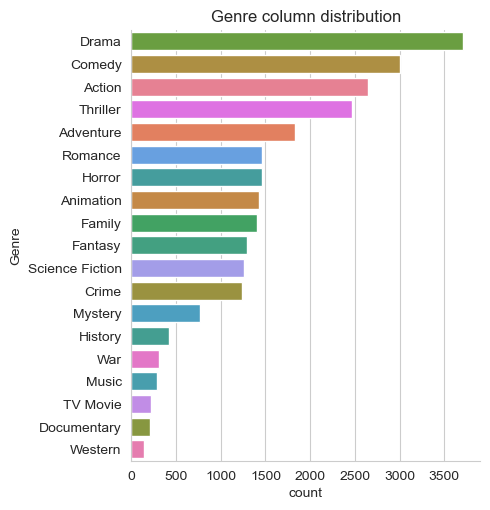

In [55]:
sns.catplot(y='Genre', data=df, kind='count', order= df['Genre'].value_counts().index, hue='Genre')
plt.title('Genre column distribution')
plt.show()

#### Which has highest votes in vote avg column?

In [57]:
df['Vote_Average'].describe()

count       25552
unique          4
top       average
freq         6613
Name: Vote_Average, dtype: object

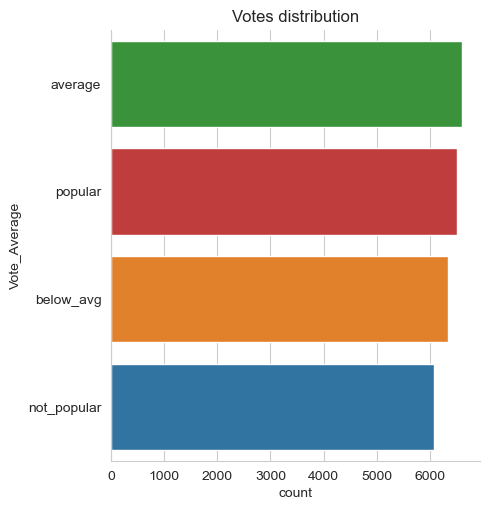

In [58]:
sns.catplot(y='Vote_Average', data=df, kind='count', order= df['Vote_Average'].value_counts().index, hue='Vote_Average')
plt.title('Votes distribution')
plt.show()

#### What movie got the highest popularity? What's its genre?

In [59]:
df[df['Popularity'] == df['Popularity'].max()]

,index,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


#### What movie got the lowest popularity? What's its genre?

In [60]:
df[df['Popularity'] == df['Popularity'].min()]

,index,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,9825,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,9825,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,9825,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,9826,1984,Threads,13.354,186,popular,War
25550,9826,1984,Threads,13.354,186,popular,Drama
25551,9826,1984,Threads,13.354,186,popular,Science Fiction


#### Which year has the most filmmed movies?

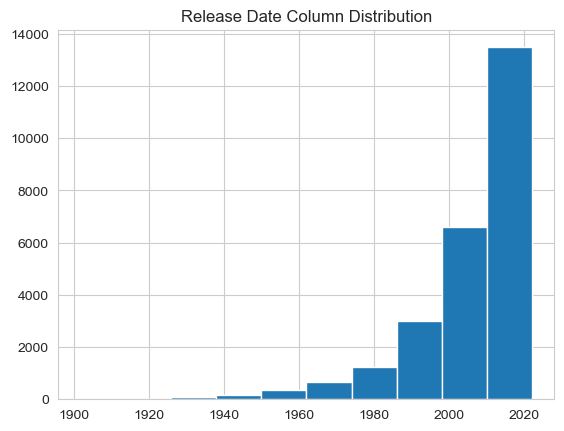

In [61]:
df['Release_Date'].hist()
plt.title('Release Date Column Distribution')
plt.show()

##### Analysis Summary